> This week's homework is basically a reimplementation of [micrograd](https://github.com/karpathy/micrograd) by Andrej Karpathy. You can also check out his excellent [video](https://youtu.be/VMj-3S1tku0?si=KzuOK-l_VCnidk7A) on it - but first, try to solve the exercise yourself 😃

# The Backpropagation Algorithm

A neural network implements a function $f_\theta$, where $\theta$ is a set of parameters. It consists of multiple layers of artificial neurons, the output of a single neuron being $\phi(\mathbf{w}^\intercal \mathbf{x} + b)$, where $\mathbf{w}$ are the neuron's weights, $b$ is the bias, and $\phi(\cdot)$ is an activation function. Training a neural network means finding the best set of parameters, which can be done by minimizing an appropriate loss function $\mathcal{L}(\theta)$: to do so, one can use the *gradient descent* algorithm, updating the parameters via the rule
  $$
  \theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta).
  $$
In general, however, the function $f_\theta$ will be extremely complicated, as the network could be easily composed by thousands, or millions, of artificial neurons: then, how can we efficiently and reliably calculate the gradient of the loss function? Before answering the question, let's briefly recap the main concepts behind derivatives.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph

## Recap: Derivatives
### General concepts
Consider a function like $f(x) = 3x^2$: below, you can see its plot.


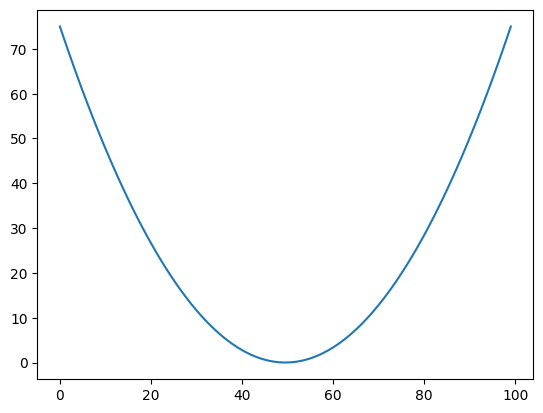

In [2]:
def f(x):
    return 3 * x ** 2

x = np.linspace(-5, 5, 100)
y = f(x)
plt.plot(y)

 You may remember from calculus that the derivative represents the istantaneous rate of change of the function: how much does $f(x)$ changes if $x$ changes by a tiny amount, say $h$? We can try and test this for a certain value of $x$ and increasingly smaller values of $h$. In the snippet below, you should that if you assign $h$ smaller and smaller values, the value of the ratio $f(x + h) - f(x))/h$ (the rise-over-run) gets closer and closer to 12.

In [9]:
x = 2
h = 0.0001
df = (f(x + h) - f(x)) / h

print(f"df = {df}")

df = 12.000300000032382


Formally, this is done through the limit
  $$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}.$$
This represents the ratio between the change in the function, $f(x + h) - f(x)$, and the change in the input, $(x + h) - x = h$, as the increment $h$ becomes infinitesimal, $\lim_{h\to 0}$. We can manually do the calculation for the simple function we considered:
  $$\lim_{h \to 0} \frac{f(x + h) - f(x)}{h} = \lim_{h \to 0} \frac{3(x + h)^2 - 3x^2}{h} =  \lim_{h \to 0} \frac{3(x^2 + 2xh + h^2) - 3x^2}{h} = \lim_{h\to 0}\frac{6xh + h^2}{h}=\lim_{h\to 0}\frac{h (6x + h)}{h} = 6x$$
which indeed confirms that when $x = 2$ its derivative equals 12!

Now, you probably remember this from your calculus class, and you also know that we don't have to apply the definition each time to get the derivative - luckily, there are easier methods. But the main idea remains this: computing the instantaneous rate of change of a function. Before moving on, let's refresh two more topics that will be useful later.

### The Chain Rule
Now, consider a composition of functions $h(x) = g(f(x))$. What is the derivative $dh/dx$? The answer is the *chain rule*: you just have to calculate the local derivatives (i.e. the derivative of each function with respect to its "direct" argument) and multiply them all, so
  $$\frac{dh}{dx} = \frac{dg}{df}\frac{df}{dx}.$$
Note that also the function from our previous example can be seen as a composition of functions: if $f_1(x) = x^2$ and $f_2(x) = 3x$, then $f(x) = f_2(f_1(x))$. In this case, the local derivatives are $f'_1(x) = 2x$ and $f'_2(x) = 3$: multiplying them, you still get $f'(x) = 6x$ as it should be.

### Multivariate Calculus
Last, we can generalize this to the multivariate case as follows: if $f$ depends on $x$ through the intermediate variables $y_1, y_2, \dots, y_n$, we just have to sum over all possible contributions, i.e.
  $$\frac{\partial f}{\partial x} = \sum_{i=1}^n \frac{\partial f}{\partial y_i}\frac{\partial y_i}{\partial x}.$$

## Computational Graphs
Now, let's describe the core of modern deep learning frameworks. When dealing with neural networks, it will be necessary to (efficiently) evaluate two quantities:
1) The *function itself* with different input values (both for the data and the parameters)
2) The *function gradient* with respect to the parameters, to use GD as our learning algorithm

For both purposes, we will make use of *computational graphs*, a clever way of representing general computations. Fundamentally, a computational graph is a directed acyclic graph, meaning it is a graph (a mathematical structure with nodes and edges) where the edges are directed (they have a starting node and an ending node) and there are no cycles (you cannot start from a node and find a path which ends up on the same node). How can we use this to represent operations? In a computational graph:
* Each node represents a variable (either an input or the result of an operation)
* Each (directed) edge represents an operation, the starting node being an argument and the ending node being the output

We can illustrate this idea with a simple example: consider the two-input function
  $$f(a, b) = (a + 2b)(b - 2).$$
For simplicity, it is useful to name intermediate variables resulting from individual operations:
  $$\begin{cases}
        c = 2b\\
        e = a + c\\
        g = b - 2
  \end{cases}$$
which will produce a graph like the one below (for simplicity, we didn't represent the nodes with costant values).

![Computational graph](https://raw.githubusercontent.com/gioviat/machine-learning-course/refs/heads/main/imgs/compgraph.png)

### Forward Pass
First of all, note that to evaluate the expression for particular values of the input we just need to substitute the actual values in the input nodes and evaluate each node in the graph in [topological order](https://en.wikipedia.org/wiki/Topological_sorting), meaning that before visiting a new node we evaluated all its dependencies, i.e. all the nodes pointing to it. We won't go into detail: for the most curious, just know that there are algorithms to sort graphs linearly in the number of vertices and edges, $O(\lvert V\rvert + \lvert E\rvert)$ - you can check them out in the linked Wikipedia page.

So, for example, if we wanted to calculate the value of $f$ for $a = 1$, $b = 2$, we would end up with

![Filled Graph](https://raw.githubusercontent.com/gioviat/machine-learning-course/refs/heads/main/imgs/filledcompgraph.png)




### Backward Pass
The real usefulness of computational graphs comes from how efficiently they allow to calculate gradients. Consider again $f(a, b) = (a + 2b)(b - 2)$: what are $\partial f/\partial a$ and $\partial f/\partial b$? Recalling the intermediate variables we defined and the chain rule, it is easy to see that
  $$\frac{\partial f}{\partial a} = \underbrace{\frac{\partial f}{\partial e}}_{g = b - 2}\underbrace{\frac{\partial e}{\partial a}}_{1} = b - 2$$
and
  $$\frac{\partial f}{\partial b} = \underbrace{\frac{\partial f}{\partial g}}_{e = a + c = a + 2b} \underbrace{\frac{\partial g}{\partial b}}_{1} + \underbrace{\frac{\partial f}{\partial e}}_{b - 2}\underbrace{\frac{\partial e}{\partial c}}_{1} \underbrace{\frac{\partial c}{\partial b}}_{2} = a + 4b - 4.$$
We can easily exploit computational graph to calculate derivatives as well. Since each edge represents a variable being used as an argument for an operation, we can label each edge with the local derivative of the output with respect to the input, as follows:

![Computational graph with derivatives](https://raw.githubusercontent.com/gioviat/machine-learning-course/refs/heads/main/imgs/dercompgraph.png)

Then, if we want to calculate the derivative of a function (e.g. the loss) with respect to some variable (e.g. the parameters of a neural network), we must simply multiply all the local derivatives along a path that goes from the variable to the function, and sum over all such paths. The key idea (and what makes this method efficient) is that many edges are shared across different paths: for example, we needed $\partial f/\partial e$ in both calculations in the example above. This is the main idea behind *reverse mode automatic differentiation*: starting from a node, we can travel the graph back to the inputs, multiplying the local derivatives along a path and merging paths together when they meet at a certain node. This way, a single backward pass gives the derivative of a function *with respect to all inputs*.

## Implementing the Backpropagation Algorithm
In this week's homework, you will build from scratch a minimal engine to build computational graphs and run the backpropagation algorithm on scalar inputs. Modern deep learning frameworks (like PyTorch, that we will discuss next week) are optimized to handle multi-dimensional inputs (tensors): but apart from this, the core idea stays the same, and hopefully today's implementation will help you in understanding what's going on under the hood when training more complicated architectures. The homework will be divided into two parts: first, building the computational graph and the forward pass (which we will do in class), and then implementing the backward pass.

### Building the Computational Graph
Let's start by defining the class which we will use to store the variables of the computations and build the computational graph. It will basically be a container for a scalar, with an attribute `data` being the actual numerical value.

In [29]:
# @title
# Helper function to incrementally add methods to the Node class
def add_method(cls):
    def decorator(func):
        setattr(cls, func.__name__, func)
        return func
    return decorator

In [30]:
class Node:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.label = label
        self._prev = set(_children)
        self._op = _op

        # New attributes for Backpropagation
        self.grad = 0.0  # Stores the derivative dL/dself

        # Placeholder function that does nothing by default
        self._backward = lambda: None

    def __repr__(self):
        return f"Node(data={self.data}, label={self.label}, grad={self.grad})"

In [31]:
a = Node(3.0)
print(a)

Node(data=3.0, label=, grad=0.0)


#### Task 1: Basic Operations
Next, we need to implement some basic operation between nodes, such as addition and multiplication: if we sum two `Node` objects, we want the result to be a `Node` as well, with `data` equal to the sum of the two addend nodes.
* Implement the `__add__()`, and `__mul__()` methods
* The result of adding or multiplying two nodes should be another node with the appropriate `data` value

In [32]:
@add_method(Node)
def __add__(self, other):
    other = other if isinstance(other, Node) else Node(other)
    out = Node(self.data + other.data, _children=(self, other), _op="+")

    def _backward():
        # Addition local derivative is 1: (1 * out.grad)
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

@add_method(Node)
def __mul__(self, other):
    other = other if isinstance(other, Node) else Node(other)
    out = Node(self.data * other.data, _children=(self, other), _op="*")

    def _backward():
        # Multiplication local derivative is the "other" value
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
    out._backward = _backward

    return out

@add_method(Node)
def __neg__(self):
    return self * -1

@add_method(Node)
def __sub__(self, other):
    return self + (-other)

In [33]:
b = Node(2.0)
c = a + b
c

Node(data=5.0, label=, grad=0.0)

#### Task 2: Node Dependencies
To build a computational graph, we need to keep track of the nodes' dependencies: this means storing both the children node (the inputs) when creating a node with an operation, and the operation itself.
* Modify the `__init__()` method to accept a `_children` argument, set by default to an empty tuple, and an `_op` argument, set by default to an empty string
* Store the set of the `_children` tuple (we are not storing the plain tuple to avoid duplicates) and the `_op` string as `Node` attributes
* Modify the `__add__()` and `__mul__()` methods to pass the appropriate nodes as `_children` in the result node, and the appropriate operation as `_op`

In [34]:
a = Node(2.0)
b = Node(3.0)
c = a * b
print(c._prev)
print(c._op)

{Node(data=3.0, label=, grad=0.0), Node(data=2.0, label=, grad=0.0)}
*


Now, we have basically all we need to build a computational graph: we can easily visualize it with the snippet below.

In [35]:
# @title
# Helper function to visualize the computational graph

def traceback(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_graph(root):
    graph = Digraph(graph_attr={'rankdir': 'LR'}, format="png")
    nodes, edges = traceback(root)

    for n in nodes:
        n_id = str(id(n))
        # Update the label to include the gradient (grad)
        # We use the record shape to create a nice multi-line box
        label_text = f"{n.label} | data={n.data:.3f} | grad={n.grad:.3f}"
        graph.node(name=n_id, label=label_text, shape="record")

        if n._op:
            op_id = n_id + n._op
            graph.node(name=op_id, label=n._op, shape="circle")
            graph.edge(op_id, n_id)

    for n1, n2 in edges:
        graph.edge(str(id(n1)), str(id(n2)) + n2._op)

    return graph

A brief note on this: first, we define a helper function, which starting from a root point constructs and returns two sets, one with the nodes and one with the edges. For the actual plotting, we define a `Digraph` object (the `rankdir` attribute is related to the direction of the graph: left-to-right or top-to-bottom). Then, we call `traceback()` to obtain the nodes and the edges with respect to the root node we are interested in. Two loops follow - the first one, on the nodes, adds each node to the graph, then checks the `op` attribute: if it is not empty, it adds another node with the operation (just for visual clarity) and an edge from the operation node to the actual node we are considering. The second loop is on the edges: for each child-parent edge in the graph, the child node is
connected to the operation node it uses to create the parent node.

We can try and create the computational graph for the simple example seen before.

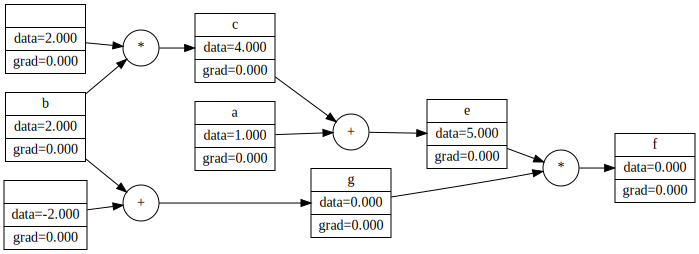

In [36]:
a = Node(data=1.0, label="a")
b = Node(data=2.0, label="b")
c = b * 2.0; c.label = "c"
e = a + c; e.label = "e"
g = b - 2.0; g.label = "g"
f = e * g; f.label = "f"

draw_graph(f)

### Running Backpropagation
You'll now implement the core of the autograd engine: the backpropagation algorithm. In what follows, we will always consider a single output $L$. Before going into detail, let's have a look at the general structure.

The main idea is to implement two different objects for different goals:
* `backward()` is a global operation which traverses the whole graph. It is the function you will actually call when performing backpropagation, e.g. with `L.backward()`, to get the gradients of all inputs with respect to some output.
* The actual gradient calculations happens locally, one node at a time, using the chain rule. To keep these concerns separate, each node will carry its own `_backward` function, responsible only for pushing gradients one step back to its children.

---

#### Task 3: Extend `__init__()`
Modify the node initialization by adding two attributes:
* `grad`, initialized to zero, will store $\partial L/\partial \text{self}$, i.e. the derivative of the output with respect to itself
* `_backward`, initialized to a function with no effect (you can use `lambda: None`), is a placeholder which stores the rule to backpropagate gradients by one step, and will be overwritten when nodes are created through some operation
* Change the `draw_graph()` function to display also the gradient. Then, run again the previous cell and check that all the gradients are correctly set to 0.

#### Task 4: Local Derivatives
When an operation creates an output node `out`, define (for each operation) a closure that, given `out.grad`, correctly updates the `grad` attributes of the input nodes exploiting the chain rule:
  $$\frac{\partial L}{\partial \text{input}} = \frac{\partial L}{\partial \text{out}} \frac{\partial \text{out}}{\partial \text{input}}.$$
The local derivative $\partial \text{out} / \partial \text{input}$ is elementary for addition, subtraction, and multiplication. Assign the closure to `out._backward`.  

> **Watch out:** what happens when the same node is used multiple times in a graph (either as both operands in a single operations, like in $a^2$, or as an input to different operations, like $b$ in our earlier example?

Now, you can manually run backpropagation one step at the time, by setting the output gradient to `1.0` and then calling `_backward()` for each node down to the inputs. Try this on the graph defined in the previous cell!

#### Task 5: The `backward()` method
Last, we wrap everything in the global `backward()` method. Here, we first get a topological order of the nodes, and then automate what you just did manually: set the output gradient to `1.0`, and the run `_backward()` on each node, from the output to the inputs. This function is already provided, so you don't have to do anything - just try to understand why the ordering is necessary and then experiment with it!


In [37]:
@add_method(Node)
def backward(self):
    ordered = []
    visited = set()

    def topological_sort(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                topological_sort(child)
            ordered.append(v)
    topological_sort(self)

    self.grad = 1.0
    for v in reversed(ordered):
        v._backward()

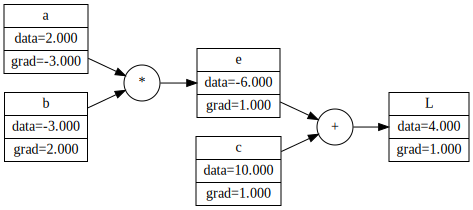

In [38]:
# 1. Define your inputs
a = Node(2.0, label='a')
b = Node(-3.0, label='b')
c = Node(10.0, label='c')

# 2. Build the graph (The Forward Pass)
e = a * b; e.label = 'e'
L = e + c; L.label = 'L'

# 3. Run the Backpropagation!
L.backward()

# 4. Look at the result
draw_graph(L)

## Where to go from here

You have now built a minimal but fully functional autograd engine from scratch. It supports the construction of arbitrary computational graphs over scalar values, a forward pass to evaluate expressions, and a backward pass that efficiently computes the gradient of any output with respect to all inputs in a single traversal: the same architecture that underlies modern deep learning frameworks like PyTorch.

For the most curious, the natural next step is to build a neural network library on top of this engine. This requires surprisingly little additional work, and can be done in three stages:

**Nonlinearities:** to implement proper artificial neuron, you must also implement activation functions, like tanh, sigmoid or ReLU. Adding them requires implementing an appropriate method in `Node`: the forward pass is straightforward, and as long as you know how to compute the derivative of the function (which you know for these ones) you can implement the bacwkard pass.

**Neurons, layers, and the MLP:** once you have your activation function, you can implement an artificial neuron, computing $\phi(\mathbf{w}^\intercal \mathbf{x} + b).$ Since all of these operations are already supported by
`Node`, implementing a `Neuron` class amounts to initializing random weights and a bias as `Node` objects, and defining a `__call__` method that computes the output. A `Layer` is then a collection of independent neurons all receiving the same input, and an `MLP` chains several layers together, passing the output of one as the input to the next. A useful abstraction is a `Module` base class, analogous to `torch.nn.Module`, which each component inherits from and which provides a `parameters()` method to collect all learnable `Node` objects, and a `zero_grad()` method to reset their gradients before each backward pass.

**The training loop:** once the model is defined, training follows the same four steps at every iteration: (1) run the inputs through the model to get predictions (forward pass), (2) aggregate the per-sample errors into an appropriate scalar loss, (3) call `loss.backward()` to fill the `grad` attribute of every node, and finally update each parameter by nudging its `.data` in the direction of steepest descent: $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$. Note that the update operates directly on
`.data`, outside the computational graph: a new graph is built from scratch at each forward pass.

If you want to go into detail, all of this is implemented in micrograd: you are encouraged to check it out and trying to experiment with it yourself.